In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib import colormaps 
import timeit
from multiprocess import Pool
from IPython.display import Video,display
import networkx as nx
import os
import pickle
colors=plt.rcParams['axes.prop_cycle'].by_key()['color']

In [2]:
Ns=[128,128,128]
Ls=[50.,50.,50.]

filebase='data/3dcgle'
file=open('%slines.dat'%filebase, 'rb')
ids,cids,edges,lines=pickle.load(file)
file.close()
nt=len(lines)

file=open("%sfaces.dat"%(filebase),"rb")
faces=pickle.load(file)
file.close()

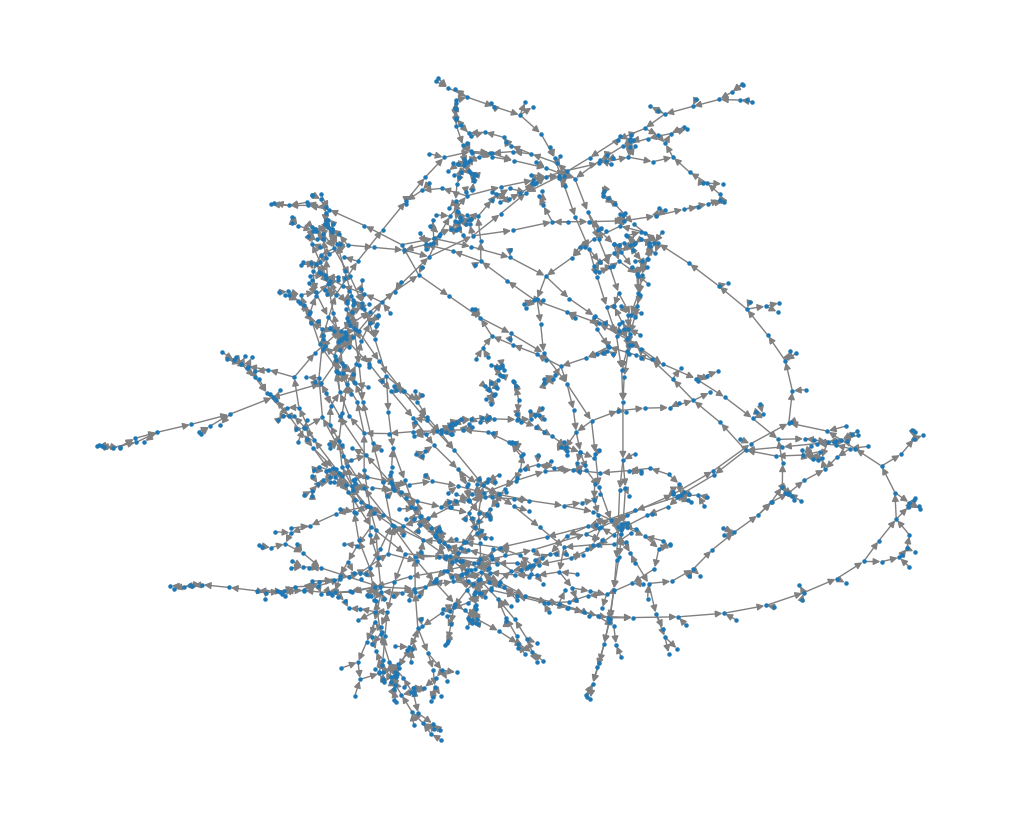

In [3]:
G=nx.DiGraph(edges)
plt.figure(figsize=(10, 8))
nx.draw(G,node_size=5,edge_color='gray')
plt.show()

plot the line ancestry as a directed acyclic graph

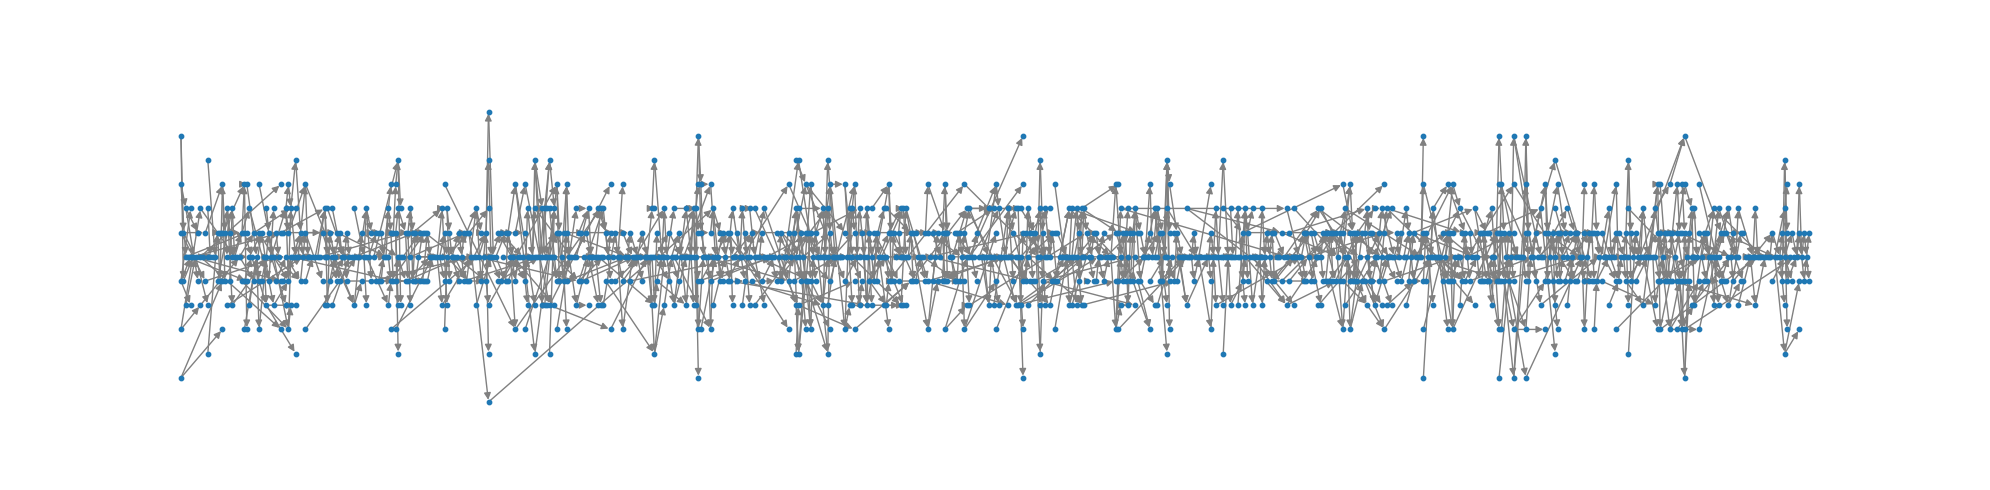

In [4]:
G=nx.DiGraph(edges)

for node in G.nodes:
    for n in range(len(lines)):
        if len(np.where(ids[n]==node)[0])>0:
            break
    G.nodes[node]["birth"] = n

pos = nx.multipartite_layout(G, subset_key="birth", align='vertical')
for key in pos.keys():
    oldval=pos[key]
    newval=np.array([oldval[0],-oldval[1]])
    pos[key]=newval
    
plt.figure(figsize=(20, 5))
nx.draw_networkx(G,pos=pos,with_labels=False,edge_color='gray',node_size=10)

plt.axis("off")
plt.tight_layout()
plt.show()

plot the lines

In [5]:
def plotlines(lines, ids, ax):
    for i in range(len(lines)):
        c=colors[np.mod(ids[i],len(colors))]
        for line in lines[i]:
            if np.linalg.norm(line[0]-line[1],ord=np.inf)<np.min(Ls)/2:
                alpha=0.25*np.linalg.norm(([0,Ls[1],0]-line[0])/Ls,ord=np.inf)
                ax.plot(*line.T,lw=1.5, marker=None, c=c, alpha=alpha)
            else:
                if (line[0][0]==0 or line[0][1]==Ls[1] or line[0][2]==0) and not (line[1][0]==0 or line[1][1]==Ls[1] or line[1][2]==0):
                    ax.scatter(*line[0],s=10,color=c,alpha=0.25)
                if (line[0][0]==Ls[0] or line[0][1]==0 or line[0][2]==Ls[2]) and not (line[1][0]==Ls[0] or line[1][1]==0 or line[1][2]==Ls[2]):
                    ax.scatter(*line[0],s=10,color=c,alpha=1.0)
                if (line[1][0]==0 or line[1][1]==Ls[1] or line[1][2]==0) and not (line[0][0]==0 or line[0][1]==Ls[1] or line[0][2]==0):
                    ax.scatter(*line[1],s=10,color=c,alpha=0.25)
                if (line[1][0]==Ls[0] or line[1][1]==0 or line[1][2]==Ls[2]) and not (line[0][0]==Ls[0] or line[0][1]==0 or line[0][2]==Ls[2]):
                    ax.scatter(*line[1],s=10,color=c,alpha=1.0)
    
    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[1])
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')

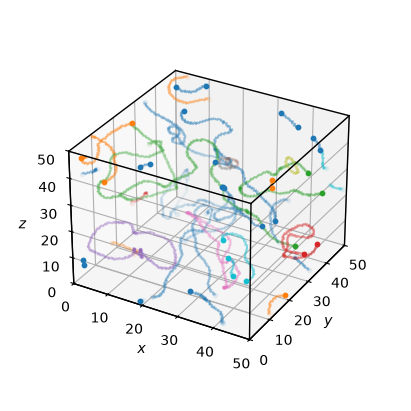

3.414157324936241


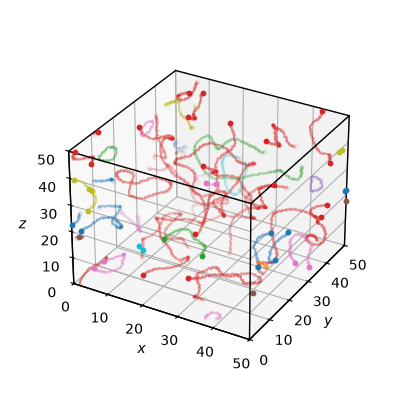

3.370182031998411


In [6]:
def makeplot(n,show=False,save=True):
    if save and os.path.exists(filebase+'animation3/%04d.png'%(n)):
        return

    fig = plt.figure(figsize=(4,4), layout='constrained')
    
    ax = fig.add_subplot(1,1,1, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    plotlines(lines[n], cids[n], ax)
    ax.set_box_aspect(aspect=None, zoom=0.8) 

    if save:
        plt.savefig(filebase+'animation3/%04d.png'%(n),bbox_inches="tight", pad_inches=0.1)
    if show:
        plt.show()
    plt.close(fig)

start=timeit.default_timer()
makeplot(0,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
makeplot(len(lines)-1,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

plot the lines alongside the faces of the fields

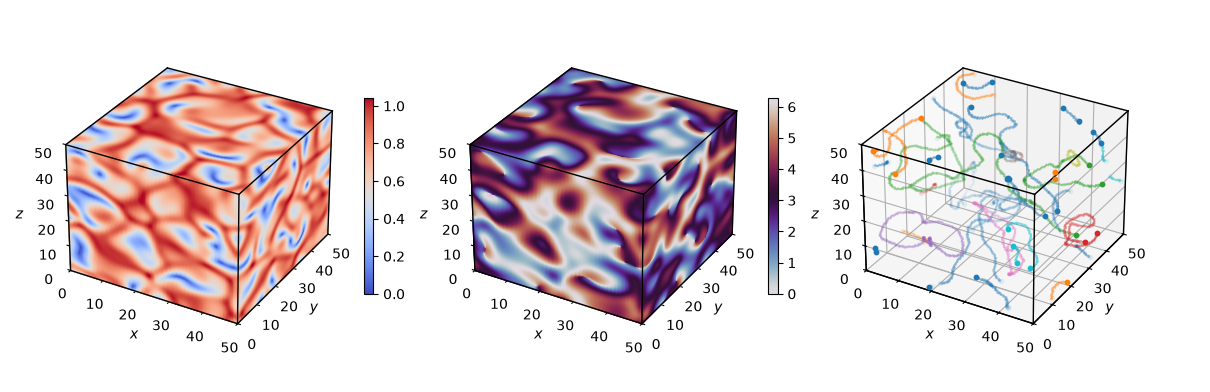

6.286618012934923


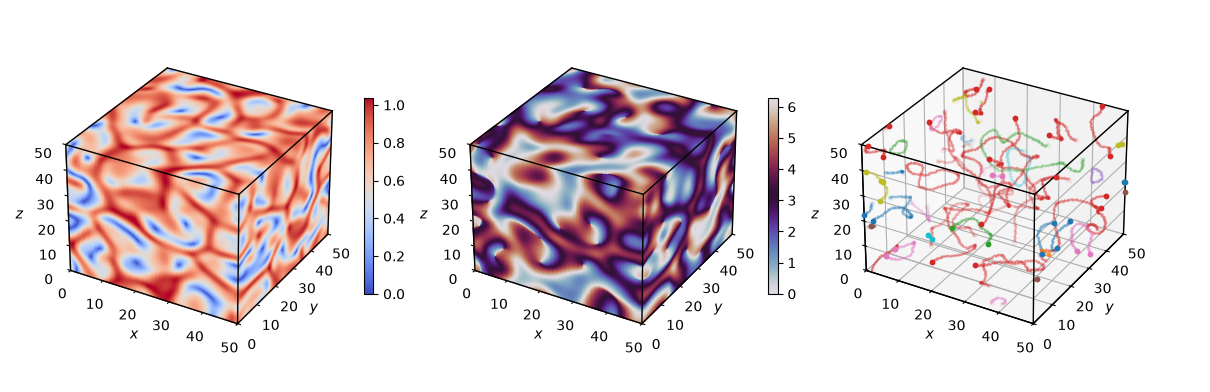

6.363860629033297


In [7]:
def plotfaces(R, ax, cmap, Rmax):
    Y,X=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[1])/Ns[1]*Ls[1])
    Z=Ls[2]*np.ones(X.shape)
    C=cmap(R[5]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    X,Z=np.meshgrid(np.arange(Ns[0])/Ns[0]*Ls[0],np.arange(Ns[2])/Ns[2]*Ls[2])
    Y=0*np.ones(X.shape)
    C=cmap(R[1].T/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    Z,Y=np.meshgrid(np.arange(Ns[1])/Ns[1]*Ls[1],np.arange(Ns[2])/Ns[2]*Ls[2])
    X=Ls[0]*np.ones(X.shape)
    C=cmap(R[3]/Rmax)
    ax.plot_surface(X,Y,Z,rstride=1, cstride=1, facecolors=C, shade=False)
    
    ax.plot([Ls[0],Ls[0]],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[0,0],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[0,Ls[1]],[0,0], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,0],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([Ls[0],Ls[0]],[Ls[1],Ls[1]],[0,Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,Ls[0]],[Ls[1],Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    ax.plot([0,0],[0,Ls[1]],[Ls[2],Ls[2]], lw=1, c='black', alpha=1, zorder=10)
    
    ax.set_xlim(0,Ls[0])
    ax.set_ylim(0,Ls[1])
    ax.set_zlim(0,Ls[2])
    
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_zlabel('$z$')
    

def makeplot2(n,show=False,save=True):
    if save and os.path.exists(filebase+'animation/%04d.png'%(n)):
        return

    fig = plt.figure(figsize=(12,4), layout='constrained')
    
    ax = fig.add_subplot(1,3,1, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    R=[np.linalg.norm(face,axis=0) for face in faces[n]]
    Rmax=np.max([np.max(face) for face in faces[n]])
    plotfaces(R, ax, plt.get_cmap('coolwarm'), Rmax)
    fig.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=Rmax), cmap=plt.get_cmap('coolwarm')),ax=ax,location='right', shrink=0.5, pad=-0.05)
    ax.set_box_aspect(aspect=None, zoom=0.8) 

    ax = fig.add_subplot(1,3,2, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    th=[np.atan2(face[1],face[0])+np.pi for face in faces[n]]
    thmax=2*np.pi
    plotfaces(th, ax, plt.get_cmap('twilight'), thmax)
    fig.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=thmax), cmap=plt.get_cmap('twilight')),ax=ax,location='right', shrink=0.5, pad=-0.05)
    ax.set_box_aspect(aspect=None, zoom=0.8) 

    ax = fig.add_subplot(1,3,3, projection='3d')
    tmp_planes = ax.zaxis._PLANES
    ax.zaxis._PLANES = (tmp_planes[2], tmp_planes[3], tmp_planes[0], tmp_planes[1], tmp_planes[4], tmp_planes[5])
    plotlines(lines[n], cids[n], ax)
    #invisible colorbar to scale the size consistently
    cbar=fig.colorbar(ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap=plt.get_cmap('gist_rainbow')),ax=ax,location='right', shrink=0.5, pad=-0.05,alpha=0)
    for spine in cbar.ax.spines.values():
        spine.set_edgecolor('white')
    cbar.ax.tick_params(color='white', labelcolor='white')

    ax.set_box_aspect(aspect=None, zoom=0.8) 

    if save:
        plt.savefig(filebase+'animation/%04d.png'%(n),bbox_inches="tight", pad_inches=0.1)
    if show:
        plt.show()
    plt.close(fig)

start=timeit.default_timer()
makeplot2(0,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

start=timeit.default_timer()
makeplot2(nt-1,show=True,save=False)
stop=timeit.default_timer()
print(stop-start)

In [ ]:
if not os.path.exists(filebase+'animation'):
    os.mkdir(filebase+'animation')
else:
    os.system('rm %sanimation/*.png'%(filebase))

print(nt)
start=timeit.default_timer()
pool=Pool(16,maxtasksperchild=1) 
pool.map(makeplot2, range(nt))
pool.close()
stop=timeit.default_timer()
print("plot time: ", stop-start)
os.system('rm -r %sanimation'%(filebase))

os.system('ffmpeg -y -r 30 -i %sanimation/'%(filebase)+'%04d.png'+ ' -c:v h264 -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2,format=yuv420p" %sanimation.mp4'%(filebase))
display(Video('%sanimation.mp4'%(filebase)))


1000
